### pykrx(Python Korea Exchange)
- 한국거래소 웹사이트에서 주식 및 지수 관련 데이터를 크롤링하여 제공
- 지원 데이터:
  - 종목 코드 및 이름
  - 일별 주가 (시가/고가/저가/종가/거래량)
  - PER, PBR, ROE 등 지표
  - KOSPI, KOSDAQ 지수
  - ETF, 상장폐지 정보 등
- 설치하기 : pip install pykrx
- 주요함수
  - | 함수                                 | 설명                        |
    | ---------------------------------- | ------------------------- |
    | `get_market_ohlcv_by_date()`       | 특정 종목의 OHLCV (일별 시세)      |
    | `get_market_ticker_list()`         | 전체 상장 종목 코드 목록            |
    | `get_market_ticker_name()`         | 종목 코드 → 종목 이름             |
    | `get_index_ohlcv_by_date()`        | 코스피/코스닥 지수 시세             |
    | `get_market_fundamental_by_date()` | PER, PBR, EPS, BPS 등 재무지표 |


In [ ]:
# !pip install openai
# !pip install pykrx
# !pip install pandas matplotlib seaborn 
# !pip install koreanize-matplotlib
# !pip install streamlit
# !pip install python-dotenv

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


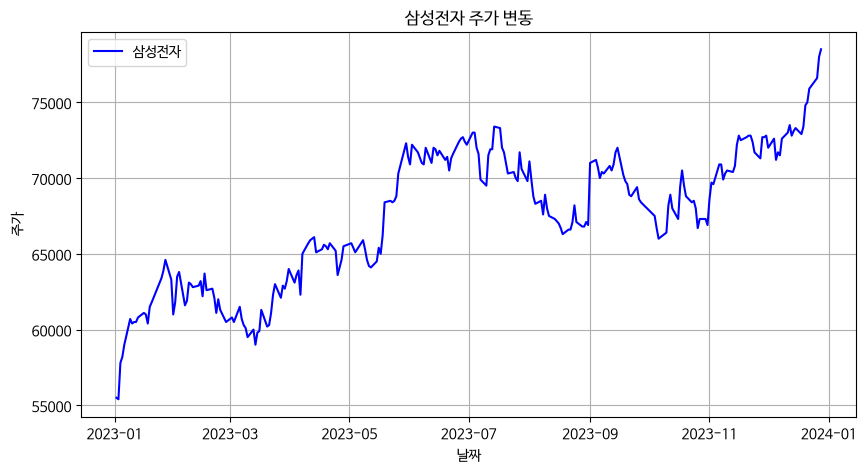

In [1]:
from pykrx import stock
import matplotlib.pyplot as plt

# 종목 코드와 기간을 지정하여 주가 데이터를 가져옴
ticker = "005930"

start_date = "2023-01-01"
end_date = "2023-12-31"

# 주가 데이터 가져오기
stock_name = stock.get_market_ticker_name(ticker)
df = stock.get_market_ohlcv_by_date(start_date, end_date, ticker)

# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['종가'], label=stock_name, color='blue')
plt.xlabel('날짜')
plt.ylabel('주가')
plt.title(f"{stock_name} 주가 변동")
plt.legend()
plt.grid()
plt.show()


In [4]:
dir(stock)

['DataFrame',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'datetime',
 'deprecated',
 'dispatch',
 'functools',
 'future_api',
 'get_business_days',
 'get_elw_ticker_list',
 'get_elw_ticker_name',
 'get_etf_isin',
 'get_etf_ohlcv_by_date',
 'get_etf_ohlcv_by_ticker',
 'get_etf_portfolio_deposit_file',
 'get_etf_price_change_by_ticker',
 'get_etf_price_deviation',
 'get_etf_ticker_list',
 'get_etf_ticker_name',
 'get_etf_tracking_error',
 'get_etf_trading_volume_and_value',
 'get_etn_ticker_list',
 'get_etn_ticker_name',
 'get_etx_ticker_list',
 'get_exhaustion_rates_of_foreign_investment',
 'get_exhaustion_rates_of_foreign_investment_by_date',
 'get_exhaustion_rates_of_foreign_investment_by_ticker',
 'get_future_ohlcv',
 'get_future_ohlcv_by_ticker',
 'get_future_ticker_list',
 'get_future_ticker_name',
 'get_index_fundamental',
 'get_index_fundamental_by_date',
 'get_index_fundamental_by_ticker',
 'get

In [2]:
import os
from openai import OpenAI
from dotenv import load_dotenv # env 파일에서 환경 변수를 불러오기 위한 라이브러리

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
model_name = os.getenv("OPENAI_DEFAULT_MODEL")

client = OpenAI(api_key=api_key)

def generate_stock_report(stock_data):
    prompt = f"""
                삼성전자의 최근 주가 변동을 분석해주세요.
                다음은 삼성전자의 종가 데이터입니다:
                {stock_data}

                이 데이터를 기반으로 가격 변동 추세와 투자에 대한 간단한 분석을 제공해주세요.
                """
    response = client.responses.create(
        model=model_name,
        input=prompt
    )
    return response.output_text

# 최근 30일 종가 데이터만 선택
df_recent = df.tail(30)

report = generate_stock_report(df_recent['종가'].tolist())
print(report)

                       

삼성전자의 종가 데이터 분석을 통해 가격 변동 추세와 투자 관점에서의 간단한 분석을 제공합니다.

### 1. 데이터 요약
주가 데이터:  
[72800, 72500, 72700, 72800, 72800, 72400, 71700, 71300, 72700, 72700, 72800, 72000, 72600, 71200, 71700, 71500, 72600, 73000, 73500, 72800, 73100, 73300, 72900, 73400, 74800, 75000, 75900, 76600, 78000, 78500]

- **최저가**: 71200
- **최고가**: 78500
- **최근 종가**: 78500

### 2. 가격 변동 추세
- 초반 주가는 대체로 72000 대에서 73000 대 사이에 머물렀습니다.
- 중반부(약 17번째 값부터)부터 가격 상승이 두드러지기 시작했으며, 특히 74800에서 78500으로의 급격한 상승을 보였습니다.
- 마지막 5일 동안 78000에서 78500으로 계속해서 상승하는 모습을 보여주고 있어 `긍정적인 기류`를 나타냅니다.

### 3. 분석
- **변동성**: 초기에는 가격이 비교적 안정적이었으나, 최근 들어 상승폭이 확대되었습니다. 이는 긍정적인 기업 실적 발표, 기술 혁신 또는 시장의 전반적인 상승 등 외부적 요인에 영향을 받았을 가능성이 있습니다.
- **매수 및 매도 신호**: 
  - **매수**: 가격이 지속적으로 상승세를 보이는 만큼 단기 투자를 고려하는 투자자에게는 매수의 기회로 작용할 수 있습니다.
  - **매도**: 그러나 가격이 빠르게 상승한 후 조정이 올 가능성도 있으므로, 장기 보유 전략을 세우고 있는 투자자는 신중할 필요가 있습니다.

### 4. 결론
삼성전자의 최근 주가는 강세를 보이고 있으며, 외부적인 요소가 긍정적으로 작용하고 있는 것처럼 보입니다. 그러나 급격한 상승 후의 조정 가능성을 염두에 두고, 투자 전략을 세우는 것이 중요합니다. 자신이 투자할 때는 시장의 전반적인 상황과 더

## 실습 : 위 2개 코드 병합하기 
-지정된 기간의 삼성전자의 주가 데이터를 조회하고, ChatGPT를 통해 분석 요청하기
- 기간 입력 , 종목코드(ticker), 프롬프트 입력받기

주식 데이터 분석 프로그램

선택 종목: 삼성전자 (005930)
조회 기간: 2025-01-01 ~ 2025-03-10


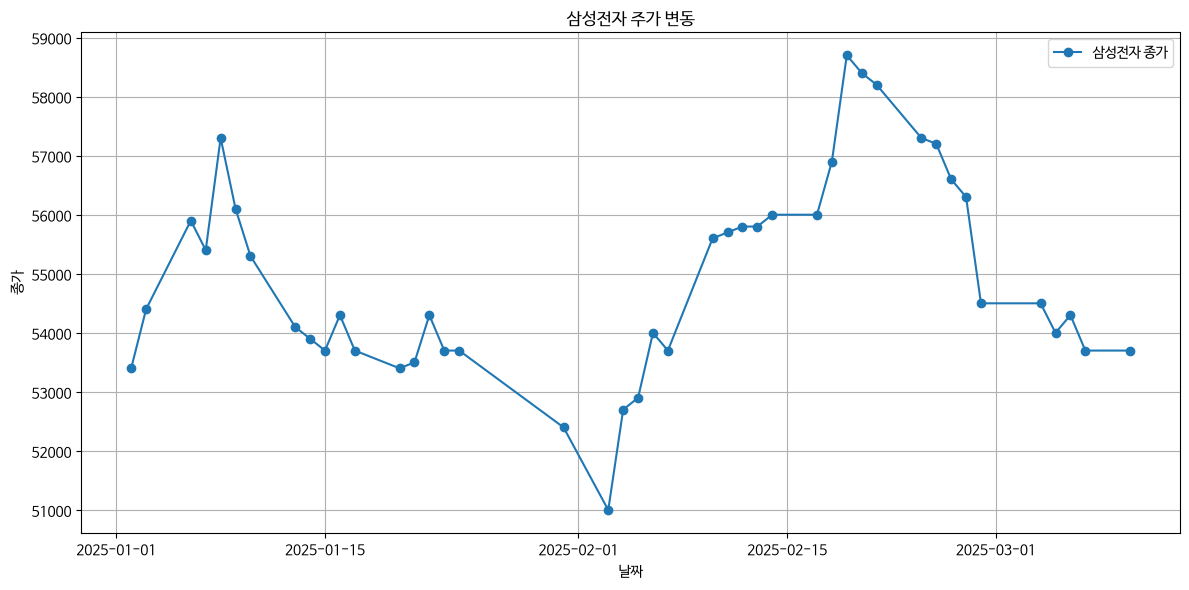


AI 분석 결과
### 삼성전자 주식 데이터 분석 (2025-01-01 ~ 2025-03-10)

#### 1. 기간 동안의 주가 추세
- **시작 종가**: 53,400원 (2025년 1월 1일)
- **종료 종가**: 53,700원 (2025년 3월 10일)

이 기간 동안 주가는 53,400원에서 53,700원으로 상승하여 300원의 상승이 있었습니다. 전체적으로 주가는 비교적 안정적으로 유지되었으며, 이는 작은 변동폭을 반영합니다.

#### 2. 상승 및 하락 흐름
- **최고 종가**: 58,700원
- **최저 종가**: 51,000원

가장 높은 가격은 58,700원이었고, 최저 가격은 51,000원이었습니다. 이 데이터는 주가가 매우 변동이 있었음을 나타내며, 특히 2월 후반에 급격한 하락이 있었고, 이후 다시 일정 범위 내에서 변동하는 모습이 관찰됩니다.

#### 3. 전체 변동성과 변동률
- **전체 변동폭**: 300원
- **전체 변동률**: 0.56%

변동폭이 300원인 것은 비교적 적은 수준으로, 주가의 안정성을 나타냅니다. 변동률 0.56% 또한 시장에서 큰 변화가 없었다는 것을 시사합니다.

#### 4. 최근 20개 거래일 데이터
최신 데이터 기반으로 보면:
- **상승 일수**: 9일 (종가가 전일보다 높음)
- **하락 일수**: 11일 (종가가 전일보다 낮음)

특히, 2월 28일에는 큰 하락이 있었으며, 이는 -3.19%의 등락률로 나타났습니다. 전반적으로 최근 일주일 간의 데이터에서도 주가는 하락세를 보인 날이 많았으나, 비교적 작은 변동이 있었습니다.

#### 결론
삼성전자의 주가는 2025년 초에 비해 소폭 상승했지만, 중간에 큰 변동성과 하락세를 겪었습니다. 전체적으로 주가는 안정된 범위에서 움직였고, 투자 시 큰 변동성을 기대하기 어려운 시장 조건임을 알 수 있습니다.


In [4]:
# pip install pykrx pandas matplotlib openai python-dotenv

import os
from dotenv import load_dotenv
from openai import OpenAI
from pykrx import stock
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------
# 1. 환경 변수 및 OpenAI 클라이언트 설정
# -------------------------------
load_dotenv()  # 환경 변수 로드
api_key = os.getenv("OPENAI_API_KEY")  # API 키 가져오기
model_name = os.getenv("OPENAI_DEFAULT_MODEL")  # 모델명 가져오기
client = OpenAI()


# -------------------------------
# 2. 종목코드 정리 함수
# -------------------------------
def normalize_ticker(ticker: str) -> str:
    """
    종목코드를 6자리 문자열로 맞춤
    예: '5930' -> '005930'
    """
    return ticker.strip().zfill(6)


# -------------------------------
# 3. 날짜 형식 정리 함수
# -------------------------------
def normalize_date(date_str: str) -> str:
    """
    YYYY-MM-DD -> YYYYMMDD 변환
    """
    return date_str.strip().replace("-", "")


# -------------------------------
# 4. 주가 데이터 조회 함수
# -------------------------------
def get_stock_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    지정 기간의 OHLCV 데이터 조회
    """
    start_date = normalize_date(start_date)
    end_date = normalize_date(end_date)

    if start_date > end_date:
        raise ValueError("시작일이 종료일보다 늦습니다.")

    df = stock.get_market_ohlcv_by_date(start_date, end_date, ticker)
    return df


# -------------------------------
# 5. 그래프 출력 함수
# -------------------------------
def plot_stock_price(df: pd.DataFrame, stock_name: str) -> None:
    """
    종가 그래프 출력
    """
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["종가"], marker="o", label=f"{stock_name} 종가")
    plt.xlabel("날짜")
    plt.ylabel("종가")
    plt.title(f"{stock_name} 주가 변동")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# -------------------------------
# 6. LLM용 데이터 요약 함수
# -------------------------------
def prepare_stock_context(df: pd.DataFrame, stock_name: str, ticker: str, start_date: str, end_date: str) -> str:
    """
    주가 데이터를 LLM 입력용 텍스트로 요약
    """
    # 빈 데이터는 여기서도 한 번 더 방어
    if df.empty:
        return f"""
                    종목명: {stock_name}
                    종목코드: {ticker}
                    분석 기간: {start_date} ~ {end_date}

                    해당 기간에는 조회된 주가 데이터가 없습니다.
                """.strip()

    first_close = df["종가"].iloc[0]
    last_close = df["종가"].iloc[-1]
    highest_close = df["종가"].max()
    lowest_close = df["종가"].min()
    avg_close = df["종가"].mean()
    total_change = last_close - first_close
    change_rate = (total_change / first_close) * 100 if first_close != 0 else 0

    recent_data = df.tail(20).reset_index()

    return f"""
                종목명: {stock_name}
                종목코드: {ticker}
                분석 기간: {start_date} ~ {end_date}

                [요약 통계]
                - 시작 종가: {first_close:,.0f}원
                - 종료 종가: {last_close:,.0f}원
                - 최고 종가: {highest_close:,.0f}원
                - 최저 종가: {lowest_close:,.0f}원
                - 평균 종가: {avg_close:,.2f}원
                - 전체 변동폭: {total_change:,.0f}원
                - 전체 변동률: {change_rate:.2f}%

                [최근 20개 거래일 데이터]
                {recent_data.to_string(index=False)}
            """.strip()


# -------------------------------
# 7. LLM 분석 함수
# -------------------------------
def generate_stock_report(stock_context: str) -> str:
    """
    고정 프롬프트로 주가 데이터를 분석
    """
    prompt = f"""
                당신은 주식 데이터 분석 도우미입니다.
                아래 데이터만 기반으로 분석해주세요.

                [주가 데이터]
                {stock_context}

                [지침]
                - 초보자도 이해할 수 있도록 쉽게 설명하세요.
                - 기간 중 추세, 상승/하락 흐름, 변동성을 설명하세요.
                - 제공된 숫자 데이터에 근거해서만 분석하세요.
                - 외부 뉴스, 재무제표, 향후 전망은 추측하지 마세요.
                - 투자 권유 문장 대신 참고용 해석으로 작성하세요.
            """

    response = client.responses.create(
        model=model_name,
        input=prompt
    )
    return response.output_text


# -------------------------------
# 8. 메인 실행 함수
# -------------------------------
def main():
    print("주식 데이터 분석 프로그램")

    try:
        # 1. 사용자로부터 종목코드와 조회 기간 입력 받기
        ticker = input("분석할 종목코드를 입력하세요 (예: 005930): ").strip()
        start_date = input("조회 시작일을 입력하세요 (예: 2026-07-07): ").strip()
        end_date = input("조회 종료일을 입력하세요 (예: 2026-07-14): ").strip()
        

        # 2. 종목코드로 종목명 조회하기
        stock_name = stock.get_market_ticker_name(normalize_ticker(ticker))

        if stock_name is None or stock_name == "":
            print("유효하지 않은 종목코드입니다.")
            return

        print(f"\n선택 종목: {stock_name} ({ticker})")
        print(f"조회 기간: {start_date} ~ {end_date}")

        # 3. 지정한 기간의 주가 데이터 가져오기
        df = get_stock_data(normalize_ticker(ticker), start_date, end_date)
        

        # 4. 조회된 데이터가 없는 경우 프로그램 종료
        if df.empty:
            print("\n해당 기간에 조회된 데이터가 없습니다.")
            print("다음을 확인해보세요.")
            print("1. 날짜가 미래가 아닌지")
            print("2. 시작일과 종료일 순서가 맞는지")
            print("3. 해당 종목이 그 기간에 거래되었는지")
            print("4. 날짜 형식이 올바른지")
            return

        
        # 5. 종가 기준 주가 그래프 출력하기
        plot_stock_price(df, stock_name)

        # 6. 주가 데이터를 LLM 입력용으로 요약하기
        prepared_context = prepare_stock_context(df, stock_name, ticker, start_date, end_date)        

        # 7. ChatGPT를 이용해 주가 데이터 분석하기
        report = generate_stock_report(prepared_context)    
        

        # 9. AI 분석 결과 출력하기
        print("\n" + "=" * 60)
        print("AI 분석 결과")
        print("=" * 60)
        print(report)

    except Exception as e:
        # 10. 실행 중 오류가 발생하면 오류 메시지 출력하기
        print(f"\n오류가 발생했습니다: {e}")
        
if __name__ == "__main__":
    main()